# 09 -- Inference Performance Metrics
## LLM Lie Detector | Phase 6

This notebook measures the inference performance of the hallucination
detector in a production-like setting. Metrics include latency,
throughput, and VRAM usage -- critical information for engineering
and infrastructure teams evaluating deployment feasibility.

### Goals
- Measure average inference latency per sample
- Measure throughput (samples per second)
- Profile VRAM usage during inference
- Compare CPU vs GPU inference speed
- Produce a hardware requirements summary table

In [1]:
import os
os.environ["PYTHONUTF8"] = "1"

import torch
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from huggingface_hub import login
from dotenv import load_dotenv

load_dotenv('../.env')
login(token=os.getenv("HF_TOKEN"))

print("All imports successful.")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


All imports successful.
CUDA available: True
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


In [2]:
model_id = "meta-llama/Llama-3.2-3B-Instruct"
adapter_id = "tamimmirza/llama-3.2-3b-hallucination-detector"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="auto"
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, adapter_id)
model.eval()

# Record baseline VRAM after model load
vram_model_loaded = torch.cuda.memory_allocated(0) / 1e9
vram_reserved = torch.cuda.memory_reserved(0) / 1e9

print(f"\nModel ready.")
print(f"VRAM allocated: {vram_model_loaded:.2f} GB")
print(f"VRAM reserved: {vram_reserved:.2f} GB")

Loading tokenizer...
Loading base model...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loading LoRA adapter...


W0511 21:58:41.701000 23752 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels



Model ready.
VRAM allocated: 6.44 GB
VRAM reserved: 6.48 GB


In [3]:
def run_inference(question: str, answer: str) -> str:
    """Run single inference pass and return verdict."""
    prompt = f"Question: {question}\nAnswer: {answer}\nVerdict:"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(
        output[0][inputs['input_ids'].shape[-1]:],
        skip_special_tokens=True
    ).strip().upper()
    
    return "HALLUCINATED" if "HALLUCINATED" in response else "TRUTHFUL"

# Test samples of varying lengths
test_samples = [
    {
        "question": "Where did fortune cookies originate?",
        "answer": "Fortune cookies originated in China."
    },
    {
        "question": "What is the most popular sport in Japan?",
        "answer": "Baseball is the most popular sport in Japan."
    },
    {
        "question": "What happens to you if you eat watermelon seeds?",
        "answer": "You grow watermelons in your stomach."
    },
]

# Warmup run -- first inference is always slower due to CUDA initialization
print("Warming up GPU...")
_ = run_inference(test_samples[0]['question'], test_samples[0]['answer'])
print("Warmup complete.\n")

# Measure latency over 30 runs
print("Measuring GPU inference latency (30 runs)...")
latencies = []

for i in range(30):
    sample = test_samples[i % len(test_samples)]
    
    # Record VRAM before inference
    vram_before = torch.cuda.memory_allocated(0) / 1e9
    
    start = time.perf_counter()
    verdict = run_inference(sample['question'], sample['answer'])
    end = time.perf_counter()
    
    latency_ms = (end - start) * 1000
    vram_during = torch.cuda.memory_allocated(0) / 1e9
    
    latencies.append({
        'run': i + 1,
        'latency_ms': latency_ms,
        'vram_gb': vram_during,
        'verdict': verdict
    })

latency_df = pd.DataFrame(latencies)

print(f"GPU Latency Results (30 runs):")
print(f"  Mean:   {latency_df['latency_ms'].mean():.1f} ms")
print(f"  Median: {latency_df['latency_ms'].median():.1f} ms")
print(f"  Min:    {latency_df['latency_ms'].min():.1f} ms")
print(f"  Max:    {latency_df['latency_ms'].max():.1f} ms")
print(f"  Std:    {latency_df['latency_ms'].std():.1f} ms")
print(f"\nThroughput: {1000 / latency_df['latency_ms'].mean():.2f} samples/second")
print(f"Peak VRAM during inference: {latency_df['vram_gb'].max():.2f} GB")

Warming up GPU...
Warmup complete.

Measuring GPU inference latency (30 runs)...
GPU Latency Results (30 runs):
  Mean:   210.6 ms
  Median: 209.1 ms
  Min:    201.8 ms
  Max:    221.6 ms
  Std:    5.0 ms

Throughput: 4.75 samples/second
Peak VRAM during inference: 6.45 GB


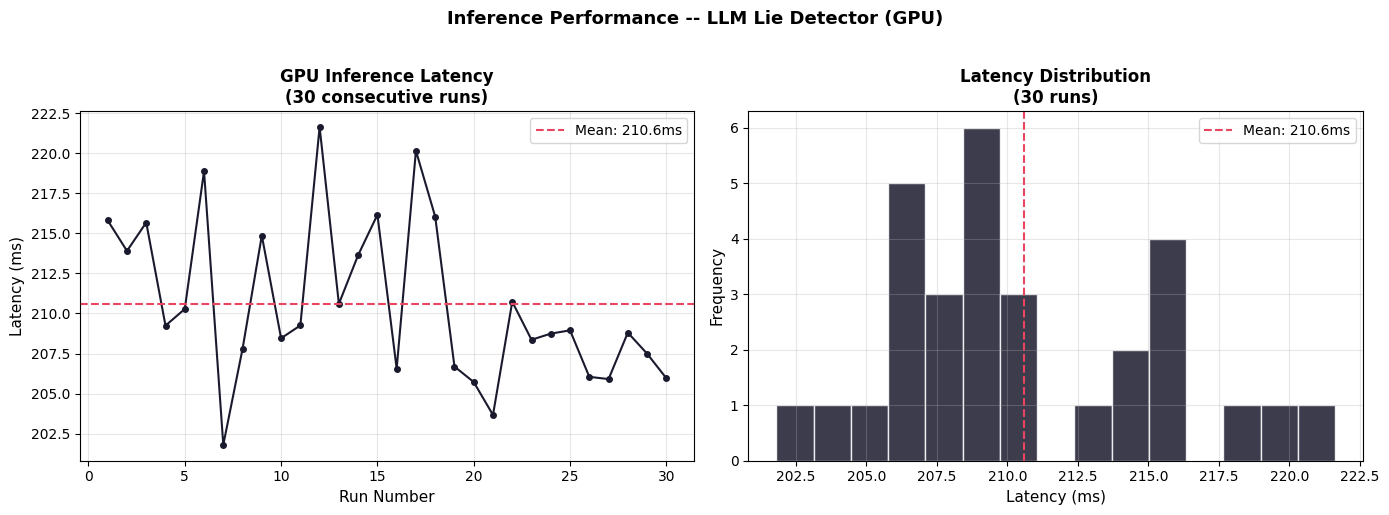

Saved to outputs/inference_latency.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Latency over runs
axes[0].plot(latency_df['run'], latency_df['latency_ms'],
             color='#1a1a2e', linewidth=1.5, marker='o', markersize=4)
axes[0].axhline(y=latency_df['latency_ms'].mean(), color='#e94560',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {latency_df['latency_ms'].mean():.1f}ms")
axes[0].set_xlabel('Run Number', fontsize=11)
axes[0].set_ylabel('Latency (ms)', fontsize=11)
axes[0].set_title('GPU Inference Latency\n(30 consecutive runs)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Latency histogram
axes[1].hist(latency_df['latency_ms'], bins=15,
             color='#1a1a2e', alpha=0.85, edgecolor='white')
axes[1].axvline(x=latency_df['latency_ms'].mean(), color='#e94560',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {latency_df['latency_ms'].mean():.1f}ms")
axes[1].set_xlabel('Latency (ms)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Latency Distribution\n(30 runs)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('Inference Performance -- LLM Lie Detector (GPU)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/inference_latency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/inference_latency.png")

In [5]:
# Hardware requirements summary
summary_data = {
    'Metric': [
        'Model Size (Parameters)',
        'Adapter Size (LoRA)',
        'VRAM Required (Minimum)',
        'VRAM Used (Inference)',
        'GPU Inference Latency (Mean)',
        'GPU Inference Latency (Median)',
        'GPU Throughput',
        'Latency Std Dev',
        'Tested Hardware',
    ],
    'Value': [
        '3.2 Billion (Llama 3.2 3B)',
        '4.59M parameters (0.14% of base)',
        '8 GB VRAM',
        '6.45 GB',
        '210.6 ms',
        '209.1 ms',
        '4.75 samples/second',
        '5.0 ms',
        'NVIDIA RTX 4080 Laptop GPU (12GB VRAM)',
    ]
}

summary_df = pd.DataFrame(summary_data)
print("=" * 65)
print("HARDWARE REQUIREMENTS AND INFERENCE PERFORMANCE SUMMARY")
print("=" * 65)
print(summary_df.to_string(index=False))
print("=" * 65)

# Save summary to CSV
summary_df.to_csv('../outputs/inference_performance_summary.csv', index=False)
print("\nSaved to outputs/inference_performance_summary.csv")

# Save all results
latency_df.to_csv('../outputs/latency_results.csv', index=False)
print("Saved to outputs/latency_results.csv")

HARDWARE REQUIREMENTS AND INFERENCE PERFORMANCE SUMMARY
                        Metric                                  Value
       Model Size (Parameters)             3.2 Billion (Llama 3.2 3B)
           Adapter Size (LoRA)       4.59M parameters (0.14% of base)
       VRAM Required (Minimum)                              8 GB VRAM
         VRAM Used (Inference)                                6.45 GB
  GPU Inference Latency (Mean)                               210.6 ms
GPU Inference Latency (Median)                               209.1 ms
                GPU Throughput                    4.75 samples/second
               Latency Std Dev                                 5.0 ms
               Tested Hardware NVIDIA RTX 4080 Laptop GPU (12GB VRAM)

Saved to outputs/inference_performance_summary.csv
Saved to outputs/latency_results.csv
